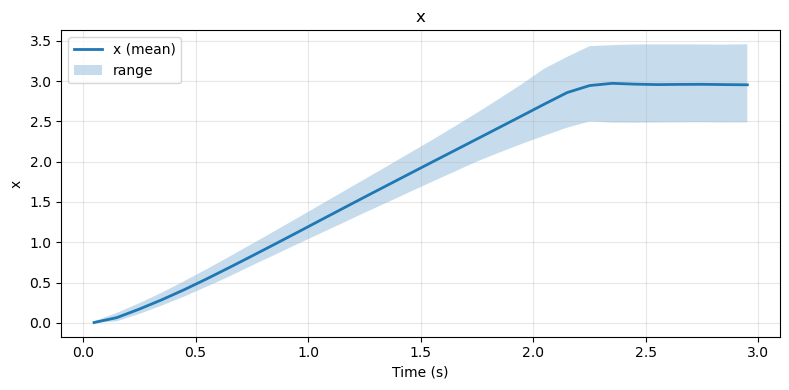

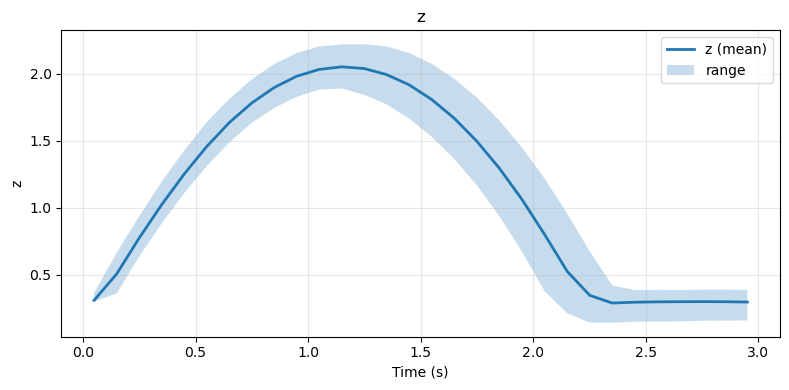

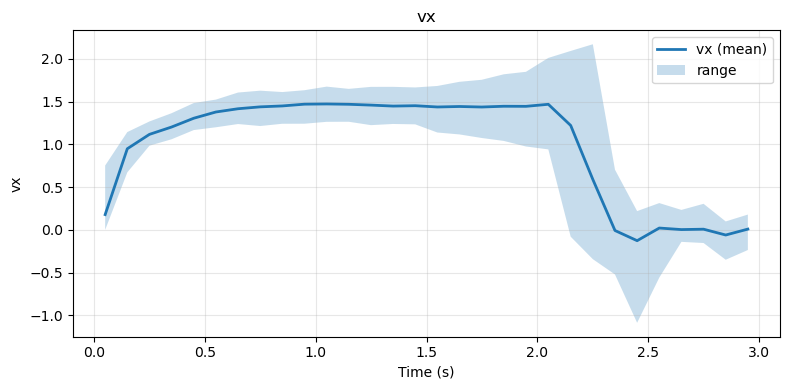

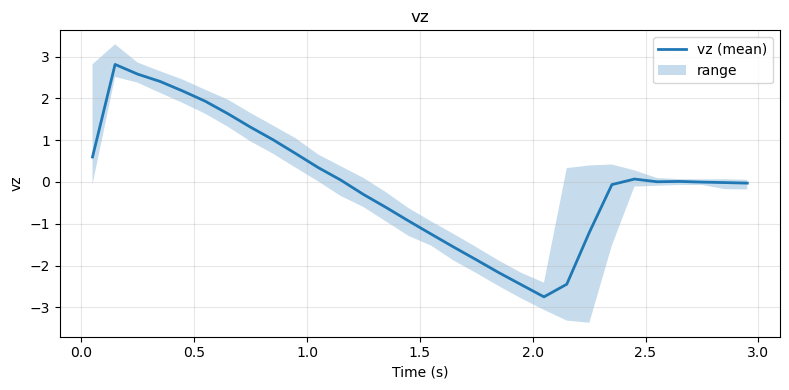

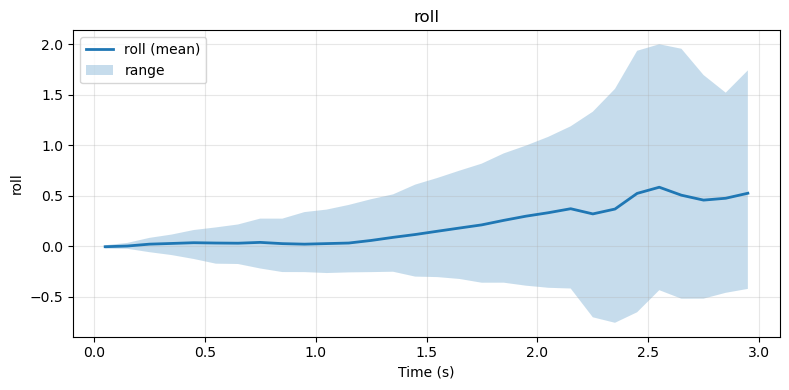

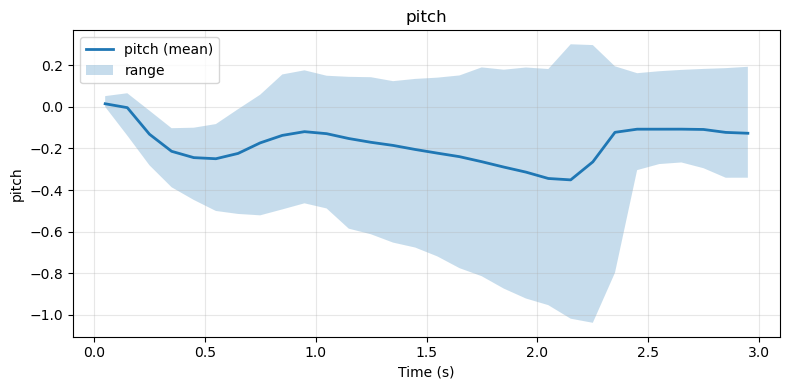

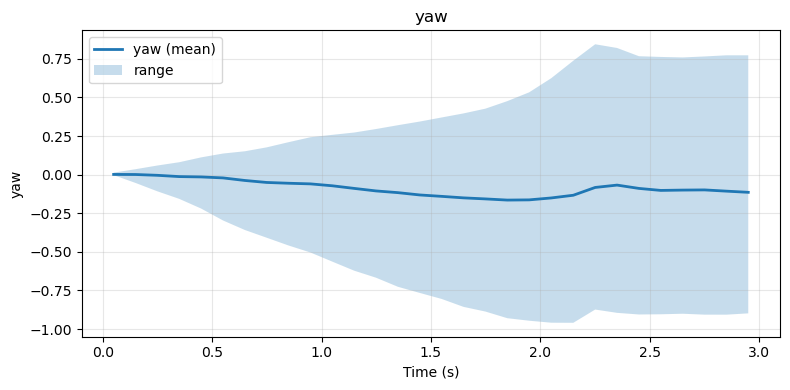

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1. 读取 CSV
# ----------------------------
df = pd.read_csv("traj_trench.csv")
df["z"] -=3.0
# 你保存的列应包含：
# t, x, z, vx, vz, roll, pitch, yaw
# 你可以选择要画的字段
fields_to_plot = ["x", "z", "vx", "vz", "roll", "pitch", "yaw"]

# ----------------------------
# 2. 设定时间窗口（例如每 0.1 秒一个窗口）
# ----------------------------
window = 0.1   # seconds per segment

# 添加 bin index
df["bin"] = (df["t"] / window).astype(int)

# ----------------------------
# 3. 对每个窗口求均值、最大值、最小值
# ----------------------------
mean_df = df.groupby("bin")[fields_to_plot].mean()
min_df  = df.groupby("bin")[fields_to_plot].min()
max_df  = df.groupby("bin")[fields_to_plot].max()

# 对应的时间序列（均值时间）
t_vals = df.groupby("bin")["t"].mean()

# ----------------------------
# 4. 绘图函数（带浅色范围）
# ----------------------------
def plot_with_range(t, mean_val, min_val, max_val, title):
    plt.figure(figsize=(8, 4))
    plt.plot(t, mean_val, label=f"{title} (mean)", linewidth=2)

    # 浅色范围填充（min-max）
    plt.fill_between(t, min_val, max_val, alpha=0.25, label="range")

    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ----------------------------
# 5. 对每个字段绘制图像
# ----------------------------
for field in fields_to_plot:
    plot_with_range(
        t_vals,
        mean_df[field].values,
        min_df[field].values,
        max_df[field].values,
        field
    )


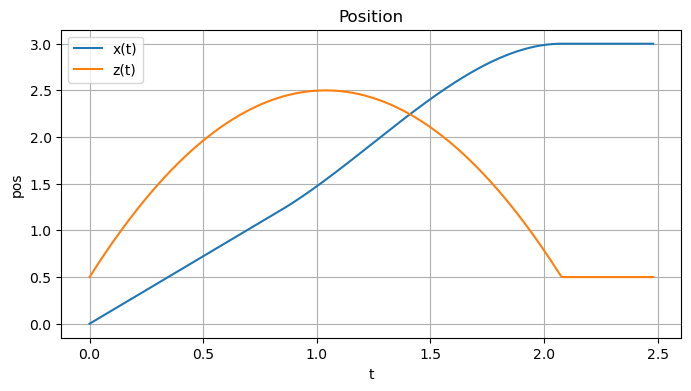

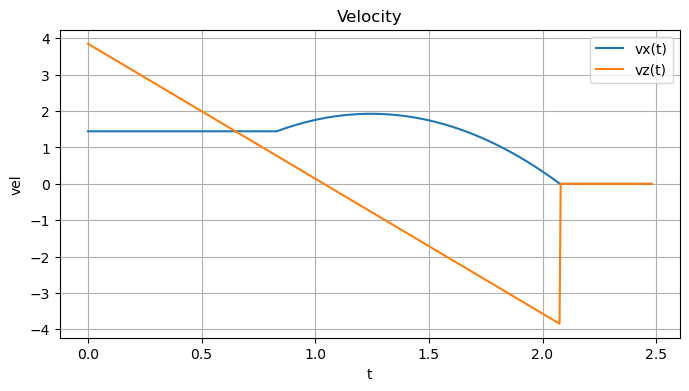

In [9]:
import numpy as np
from dataclasses import dataclass
import matplotlib.pyplot as plt
@dataclass
class LunarJumpCfg:
    z0: float = 0.5          # 站立高度
    g: float = 3.71          # 重力（你这里是火星）
    h_peak: float = 2.0      # 抬升高度（相对 z0）
    L: float = 3.0           # 水平跨越距离
    T_buffer: float = 0.4    # 落地后缓冲时间
    const_ratio: float = 0.4 # 前多少比例时间用匀速（比如 40%）

class LunarJumpRef:
    def __init__(self, cfg=LunarJumpCfg()):
        self.cfg = cfg

        # 垂直方向：物理抛物线
        self.v0z = float(np.sqrt(2 * cfg.g * cfg.h_peak))
        self.t_up = self.v0z / cfg.g
        self.T_flight = 2 * self.t_up           # 空中总时间
        self.T = self.T_flight + cfg.T_buffer   # 加上缓冲段

        # 水平平均速度（用来定义 v_const）
        self.v_const = cfg.L / self.T_flight

        # 匀速阶段结束时间
        self.t1 = cfg.const_ratio * self.T_flight

        # 匀速阶段末状态
        self.x1 = self.v_const * self.t1
        self.dx = cfg.L - self.x1
        self.T2 = self.T_flight - self.t1

    # --- x(t), vx(t): 先匀速，再减速 ---
    def x(self, t):
        c = self.cfg
        if t <= self.t1:
            # 匀速
            return self.v_const * t
        elif t <= self.T_flight:
            # 平滑减速段
            s = (t - self.t1) / self.T2  # 0~1
            f = -s**3 + s**2 + s         # 位置基函数
            return self.x1 + self.dx * f
        else:
            # 落地后水平位置保持在 L
            return c.L

    def vx(self, t):
        c = self.cfg
        if t <= self.t1:
            return self.v_const
        elif t <= self.T_flight:
            s = (t - self.t1) / self.T2
            fp = -3*s**2 + 2*s + 1       # f'(s)
            return self.dx * fp / self.T2
        else:
            return 0.0

    # --- z(t), vz(t): 抛物线 + 缓冲 ---
    def z(self, t):
        c = self.cfg
        if t <= self.T_flight:
            return c.z0 + self.v0z*t - 0.5*c.g*t*t
        else:
            return c.z0

    def vz(self, t):
        c = self.cfg
        if t <= self.T_flight:
            return self.v0z - c.g*t
        else:
            return 0.0

    def ref(self, t):
        """返回 x_ref, z_ref, vx_ref, vz_ref"""
        return self.x(t), self.z(t), self.vx(t), self.vz(t)

cfg = LunarJumpCfg()
ref = LunarJumpRef(cfg)
dt = 0.005  # 仿真时间步长
ts = np.arange(0, ref.T + dt, dt)  # 从 0 到 T，每步 0.005s

xs  = np.array([ref.x(t)  for t in ts])
zs  = np.array([ref.z(t)  for t in ts])
vxs = np.array([ref.vx(t) for t in ts])
vzs = np.array([ref.vz(t) for t in ts])

df = pd.DataFrame({
    "t": ts,
    "x": xs,
    "z": zs,
    "vx": vxs,
    "vz": vzs,
})

df.to_csv("reference.csv", index=False)
plt.figure(figsize=(8,4))
plt.plot(ts, xs, label="x(t)")
plt.plot(ts, zs, label="z(t)")
plt.legend(); plt.grid(); plt.title("Position"); plt.xlabel("t"); plt.ylabel("pos")
plt.show()

plt.figure(figsize=(8,4))
plt.plot(ts, vxs, label="vx(t)")
plt.plot(ts, vzs, label="vz(t)")
plt.legend(); plt.grid(); plt.title("Velocity"); plt.xlabel("t"); plt.ylabel("vel")
plt.show()


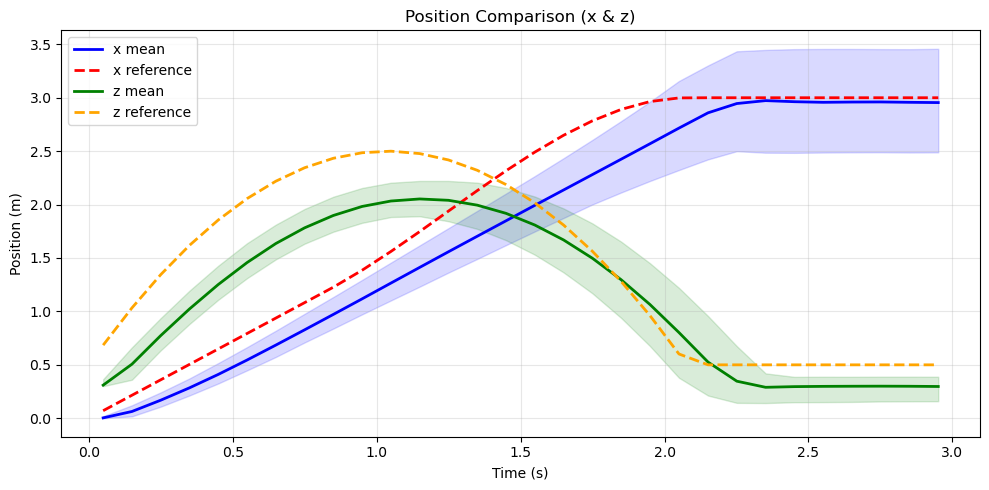

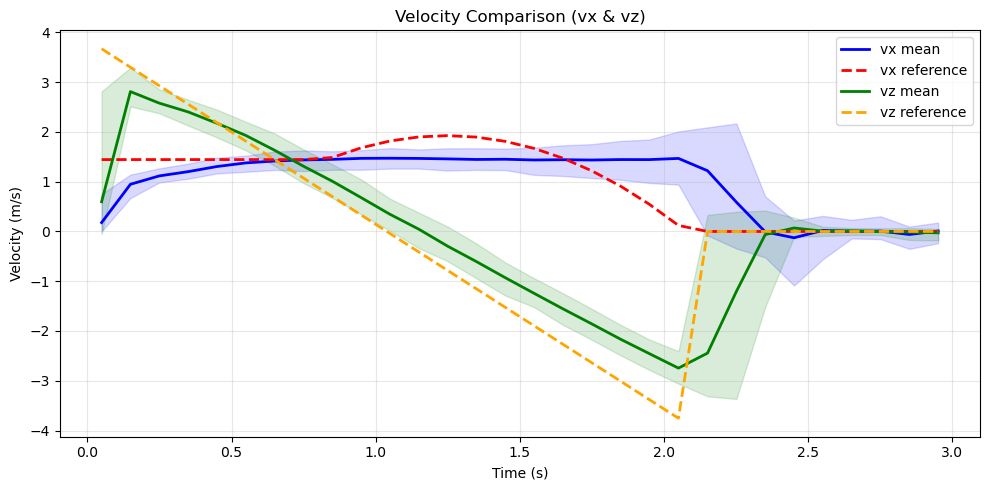

In [14]:
# 读取参考轨迹
ref = pd.read_csv("reference.csv")

# 插值参考轨迹到实际的 t_vals
ref_x  = np.interp(t_vals, ref["t"], ref["x"])
ref_z  = np.interp(t_vals, ref["t"], ref["z"])
ref_vx = np.interp(t_vals, ref["t"], ref["vx"])
ref_vz = np.interp(t_vals, ref["t"], ref["vz"])

plt.figure(figsize=(10,5))

# --- x ---
plt.plot(t_vals, mean_df["x"], label="x mean", color="blue", linewidth=2)
plt.fill_between(t_vals, min_df["x"], max_df["x"], color="blue", alpha=0.15)
plt.plot(t_vals, ref_x, label="x reference", color="red", linestyle="--", linewidth=2)

# --- z ---
plt.plot(t_vals, mean_df["z"], label="z mean", color="green", linewidth=2)
plt.fill_between(t_vals, min_df["z"], max_df["z"], color="green", alpha=0.15)
plt.plot(t_vals, ref_z, label="z reference", color="orange", linestyle="--", linewidth=2)

plt.title("Position Comparison (x & z)")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))

# --- vx ---
plt.plot(t_vals, mean_df["vx"], label="vx mean", color="blue", linewidth=2)
plt.fill_between(t_vals, min_df["vx"], max_df["vx"], color="blue", alpha=0.15)
plt.plot(t_vals, ref_vx, label="vx reference", color="red", linestyle="--", linewidth=2)

# --- vz ---
plt.plot(t_vals, mean_df["vz"], label="vz mean", color="green", linewidth=2)
plt.fill_between(t_vals, min_df["vz"], max_df["vz"], color="green", alpha=0.15)
plt.plot(t_vals, ref_vz, label="vz reference", color="orange", linestyle="--", linewidth=2)

plt.title("Velocity Comparison (vx & vz)")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


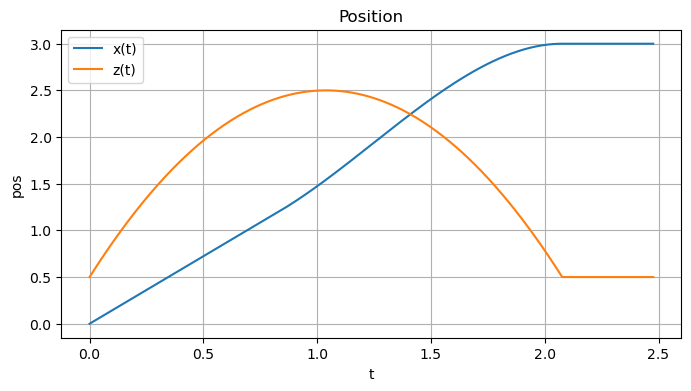

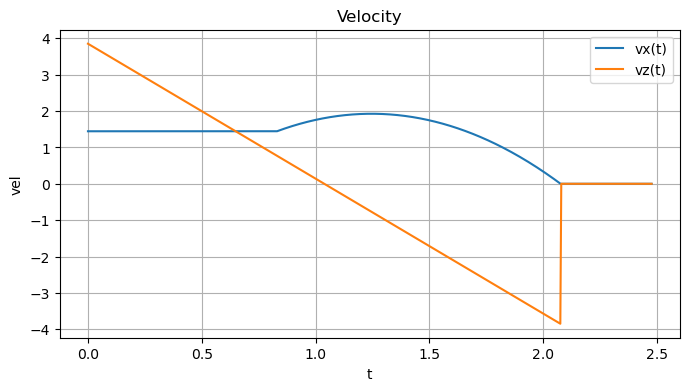